## Exercise 1.17

Write a program to generate the first $n$ terms in the sequence given by the difference equation

$$
x_{k+1}=2.25x_k-0.5x_{k-1}
$$

with starting values

$$
x_1=\frac{1}{3}
$$

and

$$
x_2=\frac{1}{12}
$$

Use

$$
n=25
$$

if you are working in single precision, and

$$
n=60
$$

if you are working in double precision.

Make a **semilog plot** of the values you obtain as a function of $k$.

The exact solution of the difference equation is given by

$$
x_k=\frac{4^{1-k}}{3}
$$

which decreases monotonically as $k$ increases.

Does your graph confirm this theoretically expected behavior?

Can you explain your results?

**Hint:** Find the general solution to the difference equation.

## 1. Setup
Usaremos la librería `math` para calcular el exponente "real", `pandas` para organizar los resultados en una tabla y `matplotlib` para las gráficas. 

In [2]:
import math
import pandas as pd
import matplotlib.pyplot as plt

## 2. Definición de variables, ¿Cómo obtendremos cada una?

- **Secuencia aproximada:** generada con la ecuación de diferencias $x_{k+1} = 2.25x_k - 0.5x_{k-1}$, partiendo de $x_1=\tfrac{1}{3}$ y $x_2=\tfrac{1}{12}$, calculada iterativamente término a término.
- **Solución exacta:** $x_k = \dfrac{4^{1-k}}{3}$, la solución cerrada de la ecuación de diferencias (obtenida resolviendo la ecuación característica $r^2-2.25r+0.5=0$, con raíces $r=2$ y $r=\tfrac14$; las condiciones iniciales anulan exactamente el modo $2^k$, dejando solo el modo decreciente $(1/4)^k$).

Y las ya conocidas:
- **Absolute error:** $E_a = |x_k^{\text{exacto}} - x_k^{\text{aprox}}|$.
- **Relative error:** $r = E_a / |x_k^{\text{exacto}}|$

In [3]:
## Definición de funciones: cómputo aproximado de x_k y cálculo de errores

def generate_sequence(n):
    x = [None, 1/3, 1/12]  # x[0] no se usa; x[1]=x1, x[2]=x2
    for k in range(2, n):
        xk1 = 2.25 * x[k] - 0.5 * x[k-1]
        x.append(xk1)
    return x[1:]  # devuelve x1..xn

def exact_solution(k):
    return 4 ** (1 - k) / 3

def get_error_values(k, x_approx):
    exact = exact_solution(k)
    abs_err = abs(exact - x_approx)
    rel_err = abs_err / abs(exact)
    return exact, abs_err, rel_err

## 3. Cálculo y visualización de resultados

- Generaremos la secuencia completa con la recurrencia, para $k=1,2,\dots,n$, con $n=60$ (doble precisión)
- Se comparará cada término contra la solución exacta $x_k=4^{1-k}/3$
- Se recopilarán los datos y serán formateados como un dataframe de pandas
- Se hará un gráfico semilogarítmico (eje $y$ en escala log) de $x_k$ aproximado vs. exacto, en función de $k$

In [4]:
n = 60
seq = generate_sequence(n)

rows = []
for k in range(1, n + 1):
    approx = seq[k-1]
    exact, abs_err, rel_err = get_error_values(k, approx)
    rows.append({
        "k": k,
        "x_k (aprox)": approx,
        "x_k (exacto)": exact,
        "Abs. Error": abs_err,
        "Rel. Error": rel_err,
    })

df = pd.DataFrame(rows)
df

,k,x_k (aprox),x_k (exacto),Abs. Error,Rel. Error
0,1,3.333333e-01,3.333333e-01,0.000000e+00,0.000000e+00
1,2,8.333333e-02,8.333333e-02,0.000000e+00,0.000000e+00
2,3,2.083333e-02,2.083333e-02,1.040834e-17,4.996004e-16
3,4,5.208333e-03,5.208333e-03,2.341877e-17,4.496403e-15
4,5,1.302083e-03,1.302083e-03,4.748806e-17,3.647083e-14
5,6,3.255208e-04,3.255208e-04,9.513874e-17,2.922662e-13
6,7,8.138021e-05,8.138021e-05,1.903181e-16,2.338629e-12
7,8,2.034505e-05,2.034505e-05,3.806464e-16,1.870953e-11
8,9,5.086263e-06,5.086263e-06,7.612954e-16,1.496768e-10
9,10,1.271566e-06,1.271566e-06,1.522591e-15,1.197415e-09


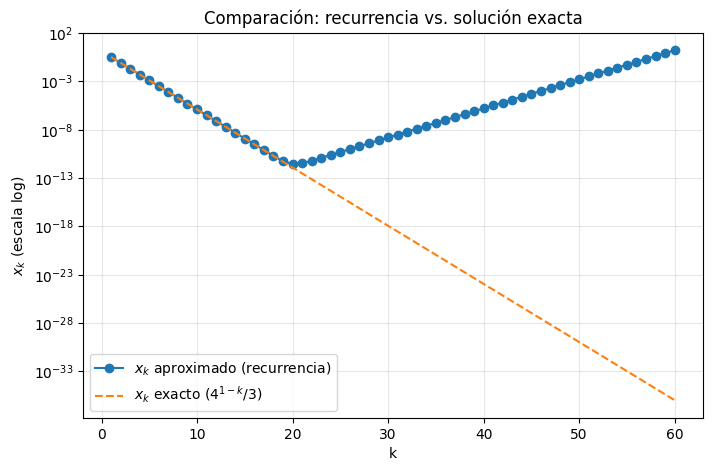

In [5]:
plt.figure(figsize=(8,5))
plt.semilogy(df["k"], df["x_k (aprox)"].abs(), 'o-', label="$x_k$ aproximado (recurrencia)")
plt.semilogy(df["k"], df["x_k (exacto)"], '--', label="$x_k$ exacto ($4^{1-k}/3$)")
plt.xlabel("k")
plt.ylabel("$x_k$ (escala log)")
plt.title("Comparación: recurrencia vs. solución exacta")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 4. Observaciones:

- **Comportamiento inicial ($k$ pequeño):** para $k\lesssim15$, el valor calculado por la recurrencia coincide casi exactamente con la solución exacta $x_k=4^{1-k}/3$ — el error absoluto y relativo son diminutos, del orden de $10^{-15}$ a $10^{-10}$.
- **Comportamiento a partir de cierto $k$ (alrededor de $k\approx20$):** la gráfica semilog muestra que $x_k$ **deja de decrecer y empieza a crecer**, apartándose por completo de la solución exacta (que sigue decayendo, cada vez más pequeña). El error relativo pasa de ser insignificante a superar el $100\%$, $1000\%$, y sigue creciendo sin control conforme aumenta $k$.

¿Qué nos dice esto? La solución general de la ecuación de diferencias es $x_k = A\cdot2^k + B\cdot(1/4)^k$, y las condiciones iniciales dadas anulan exactamente el modo creciente ($A=0$), dejando solo el modo decreciente. Pero en aritmética de punto flotante, **ningún cálculo es perfectamente exacto**: cada operación introduce un error de redondeo minúsculo, que actúa como si $A$ no fuera exactamente cero, sino un número diminuto (~$10^{-16}$). Como el modo $2^k$ crece exponencialmente mientras el modo correcto $(1/4)^k$ decae exponencialmente, tarde o temprano **esa pizca de error termina dominando por completo la secuencia** — y por eso, en vez de seguir decayendo como predice la teoría, la secuencia calculada "despega" y crece sin control. Esto es un ejemplo clásico de **inestabilidad numérica**: la recurrencia en sí es matemáticamente correcta, pero es extremadamente sensible a cualquier perturbación (por pequeña que sea) en la dirección del modo inestable $2^k$.